In [1]:
from numpy import pi, log, sqrt 
import getdist
import numpy as np
from io import StringIO
from getdist import plots, MCSamples
import random
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.integrate import odeint
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from scipy import stats
import pypolychord
from pypolychord.settings import PolyChordSettings
from pypolychord.priors import UniformPrior, GaussianPrior
import scipy.optimize as op
from numpy.linalg import inv
from mpi4py import MPI
import sympy as sp
import scipy.linalg as la
import pandas as pd

# Pantheon+SHOES Dataset (CosmoSIS Likelihood)

**Source Link:** [Pantheon+SHOES CosmoSIS Likelihood Script](https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/5_COSMOLOGY/cosmosis_likelihoods/Pantheon%2BSH0ES_cosmosis_likelihood.py)  
**Dataset Link:** [Pantheon+ Distances and Covariance](https://github.com/PantheonPlusSH0ES/DataRelease/tree/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR)

### Description

This analysis utilizes the full **STAT+SYS** covariance matrix provided in the PantheonPlus data release to construct a supernova likelihood. The approach follows the CosmoSIS likelihood format and incorporates both statistical and systematic uncertainties in the SN Ia light curves.

### Citation Guidelines

If you use this dataset or the associated likelihood script in your research, please cite the following key works:

- **Pantheon+ Compilation and Analysis Methodology:**
  - Brout et al. (2022), [arXiv:2112.03863](https://doi.org/10.48550/arXiv.2112.03863)
  - Scolnic et al. (2022), [arXiv:2202.04077](https://doi.org/10.48550/arXiv.2202.04077)

- **Covariance Matrix Construction:**
  - Conley et al. (2011), [arXiv:1104.1443](https://doi.org/10.48550/arXiv.1104.1443)

In [2]:
#Load Pantheonplus dataset and Build the Covariance Matrix
values_filename = 'datasets/sn_data/PantheonPlus/Pantheon+SH0ES.dat'
cov_filename = 'datasets/sn_data/PantheonPlus/Pantheon+SH0ES_STAT+SYS.cov'

data = pd.read_csv(values_filename, sep=r'\s+')
origlen = len(data)
ww = ((data['zHD'] > 0.01) | (data['IS_CALIBRATOR'] == 1))
zcmb = data['zHD'][ww].values
mag = data['m_b_corr'][ww].values
is_calibrator = data['IS_CALIBRATOR'][ww].values.astype(bool)
ceph_dist = data['CEPH_DIST'][ww].values

N = len(mag)

filename = cov_filename
#print("Loading covariance from {}".format(filename))
f = open(filename)
line = f.readline()
n = int(len(zcmb))
C = np.zeros((n,n))
ii = -1
jj = -1
mine = 999
maxe = -999
for i in range(origlen):
    jj = -1
    if ww[i]:
        ii += 1
    for j in range(origlen):
        if ww[j]:
            jj += 1
        val = float(f.readline())
        if ww[i]:
            if ww[j]:
                C[ii,jj] = val

f.close()
#print('Done')
cov = C
xdiag = 1/cov.diagonal()  # diagonal before marginalising constant
zmin = zcmb.min()
zmax = zcmb.max()
zmaxi = 1.1 ## we interpolate to 1.1 beyond that exact calc
print("Pantheon SN: zmin=%f zmax=%f N=%i" % (zmin, zmax, N))
ninterp=150
zinter = np.linspace(1e-3, zmaxi, ninterp)
icov = la.inv(cov)

Pantheon SN: zmin=0.001220 zmax=2.261370 N=1657


1. **Define the normalized Hubble function** $E(\theta, z)$:

$$
E(z) = \sqrt{\Omega_m (1 + z)^3 + (1 - \Omega_m)}
$$

2. **The Hubble function** $H(\theta, z)$:

$$
H(z) = H_0 \times E(z)
$$


In [3]:
#H functions
c = 299792.458

def E(theta,z):
    H0, Om, M = theta
    OL = 1 - Om
    return np.sqrt(Om*(1+z)**3 + OL)

def H(theta,z):
    H0, Om, M = theta
    arr = []
    for j in range(len(z)):
        arr.append(H0*E(theta,z[j]))
    arr = np.array(arr)
    return arr

H([67,0.32,-19],[1,2,3])

array([120.6      , 204.5421228, 308.2      ])

**Derivative of $\chi$ with respect to $z$** :

$$
\frac{d\chi}{dz} = \frac{1}{E(\theta, z)}
$$

**Integral of $\chi$** :

$$
\chi(z) = \int_0^z \frac{dz'}{E(\theta, z')}
$$


In [4]:
# function that returns dDC/dz,df/dz
def dchidz(x,z, H0, Om, M):
    return 1/E([H0, Om, M],z)

def chiInt(theta,z):
    H0, Om, M = theta
    z = np.hstack((np.array((0)), z))
    arr = odeint(dchidz,0,z,args=(H0, Om, M,))
    return np.delete(arr ,0)

chiInt([67,0.32,-19],[1,2,3])

array([0.7624812 , 1.18936468, 1.45585048])



### Luminosity Distance

$$
D_L(z_{\mathrm{HD}}) = (1 + z_{\mathrm{HD}}),\frac{c}{H_0},\chi(z_{\mathrm{HD}})
$$

### Distance Modulus

$$
\mu_{\mathrm{cosmo}}(z_{\mathrm{HD}}) = 5 \log_{10} \left[ (1 + z_{\mathrm{HD}}),\frac{c}{H_0},\chi(z_{\mathrm{HD}}) \right] + 25
$$

### SH0ES Calibration (from Pantheon+SH0ES)

$$
\mu(z) =
\begin{cases}
\mu_{\mathrm{Cepheid}}, & \text{if calibrator} \\
\mu_{\mathrm{cosmo}}(z_{\mathrm{HD}}) + M_B, & \text{otherwise}
\end{cases}
$$

In [5]:
def DL(theta,z):
    H0, Om, M = theta
    chi = chiInt(theta,z)
    return c*chi/H0

def mu(theta, z):
    H0, Om, M = theta
    dL = DL(theta, z)
    mu_th = 5 * np.log10(dL * (1 + z)) + 25
    mu_th[is_calibrator] = ceph_dist[is_calibrator]

    return mu_th + M

In [6]:
def Omega_Lambda(theta):
    H0, Om, M = theta
    OL = 1 - Om
    return OL

### Likelihood

$$
\chi^2 = (\mu_{\mathrm{obs}} - \mu_{\mathrm{model}})^T , C^{-1} , (\mu_{\mathrm{obs}} - \mu_{\mathrm{model}})
$$

$$
\ln \mathcal{L} = -\frac{1}{2}\chi^2
$$

In [7]:
def A(theta, x, y, inverse_covar):
    Mu = mu(theta, x)
    residual = y - Mu
    chi2 = residual.T @ inverse_covar @ residual
    return chi2

def lnlikeSNIa(theta):
    chi = A(theta, zcmb, mag, icov)
    i = len(zcmb)
    OL = Omega_Lambda(theta)
    return -chi, [chi, chi/(i-len(theta)),1-stats.chi2.cdf(x=chi, df=(i-len(theta))),OL]

print(lnlikeSNIa([67,0.32,-19]))

(np.float64(-15817.585387600286), [np.float64(15817.585387600286), np.float64(9.563231794196062), np.float64(0.0), 0.6799999999999999])


In [8]:
runs = 150 # n times 50 (Here n is number of free parameter)

In [9]:
def dumper(live, dead, logweights, logZ, logZerr):
    print("Last dead point:", dead[-1])

In [10]:
def uniprior(hypercube):
    prior = []
    prior.append(UniformPrior(50.,100.)(hypercube[0]))
    prior.append(UniformPrior(0.,1.)(hypercube[1]))
    prior.append(UniformPrior(-20,-18.)(hypercube[2]))
    return prior

In [11]:
settingsCCBAOPPSHOES = PolyChordSettings(3,4)
settingsCCBAOPPSHOES.file_root = 'CC + DESI DR2 + PPSHOES'
settingsCCBAOPPSHOES.nlive = runs
settingsCCBAOPPSHOES.do_clustering = True
settingsCCBAOPPSHOES.read_resume = False

In [12]:
outputCCBAOPPSHOES = pypolychord.run_polychord(lnlikeSNIa, 3,4, settingsCCBAOPPSHOES, uniprior, dumper)

PolyChord: MPI is already initilised, not initialising, and will not finalize

PolyChord: Next Generation Nested Sampling
copyright: Will Handley, Mike Hobson & Anthony Lasenby
  version: 1.22.3
  release: 22nd Nov 2025
    email: wh260@mrao.cam.ac.uk

Run Settings
nlive    :     150
nDims    :       3
nDerived :       4
Doing Clustering
Synchronous parallelisation
Generating equally weighted posteriors
Generating weighted posteriors
Clustering on posteriors
Writing a resume file to chains/CC + DESI DR2 + PPSHOES.resume

generating live points


all live points generated

Speed  1 =  0.409E-03 seconds
number of repeats:           15
started sampling

Last dead point: [ 8.06748340e+01  7.37796139e-01 -1.92990662e+01  1.14764028e+04
  6.93857486e+00  0.00000000e+00  2.62203861e-01 -1.59553336e+04
 -1.14764028e+04]
_________________
lives      | 150 |
phantoms   |1275 |
posteriors | 151 |
equals     |   1 |
‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
ncluster   =       1 /       1
ndead      =                 151


In [13]:
paramnames = [('H0','H_{0}'),('Om', r'\Omega_{m0}'),('M',r'\mathcal{M}'),((r'\chi^2_{min}', r'\chi^2_{min}')),((r'\chi^2_{red}', r'\chi^2_{red}')),('p','p'),('Omega_Lambda', r'\Omega_{\Lambda0}')]
outputCCBAOPPSHOES.make_paramnames_files(paramnames)

posteriorCCBAOPPSHOES = outputCCBAOPPSHOES.posterior

chains/CC + DESI DR2 + PPSHOES.txt
Removed no burn in


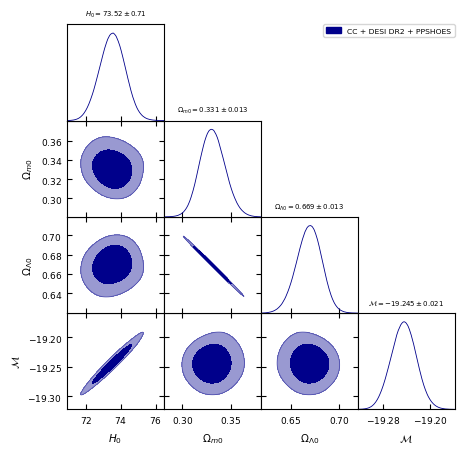

In [16]:
g = getdist.plots.getSubplotPlotter(width_inch=5.0)
g.settings.figure_legend_frame = True  # Remove frame around the legend
g.settings.alpha_filled_add = 0.6  # Adjust transparency of filled contours
g.settings.title_limit_fontsize = 9 # Limit title fontsize to 14
g.settings.axes_labelsize = 12  # Adjust label fontsize
g.settings.legend_fontsize = 10  # Adjust legend fontsize
g.settings.colorbar_axes_fontsize = 10  # Adjust colorbar fontsize
g.triangle_plot([posteriorCCBAOPPSHOES], ('H0','Om','Omega_Lambda','M') ,filled=True, contour_colors=['darkblue'], legend_loc='upper right', legend_labels=[r'CC + DESI DR2 + PPSHOES'],title_limit=1)
g.export("Plots/PP_SHOES.pdf")

In [17]:
def get_constraints(samples):
    for i, mean in enumerate(samples.getMeans()):
        upper = samples.confidence(i, upper=True, limfrac=0.05)
        #print("\nupper limit 95 C.L. = %f" % upper)
        lower = samples.confidence(i, upper=False, limfrac=0.05)
        #print("lower limit 95 C.L. = %f" % lower)
        print("%s = %f +/- %f +/- %f" % (samples.parLabel(i),\

        mean, mean - samples.confidence(i, limfrac=0.16),\
        mean - samples.confidence(i, limfrac=0.025)) )
    return
for i in ['CCBAOPPSHOES']:
    print(i)
    get_constraints(eval("posterior"+i))

CCBAOPPSHOES
H_{0} = 73.515328 +/- 0.693718 +/- 1.396468
\Omega_{m0} = 0.330964 +/- 0.012887 +/- 0.023396
\mathcal{M} = -19.244797 +/- 0.020291 +/- 0.041096
\chi^2_{min} = 1454.137699 +/- 1.045710 +/- 1.384539
\chi^2_{red} = 0.879164 +/- 0.000632 +/- 0.000837
p = 0.999849 +/- 0.000012 +/- 0.000039
\Omega_{\Lambda0} = 0.669036 +/- 0.012418 +/- 0.025231


### Here We Compute The Log Of Bayesian Evidence


In [18]:
outputCCBAOPPSHOES

Global evidence:
log(Z)    -1465.151828 +/-  0.271046

Local evidences:
log(Z_1)    -1465.151828 +/-  0.271046

Run-time information:
ncluster           1
nposterior      3066
nequals          466
ndead           3066
nlive              0
nlike         191974
<nlike>        [0.0]

Parameter estimates:
H0            H_{0}                 7.352E+01 +/- 7.290E-01
Om            \Omega_{m0}           3.310E-01 +/- 1.264E-02
M             \mathcal{M}          -1.924E+01 +/- 2.148E-02
\chi^2_{min}  \chi^2_{min}          1.454E+03 +/- 1.376E+00
\chi^2_{red}  \chi^2_{red}          8.792E-01 +/- 8.319E-04
p             p                     9.998E-01 +/- 1.673E-05
Omega_Lambda  \Omega_{\Lambda0}     6.690E-01 +/- 1.264E-02